In [1]:
import sys, warnings
from pathlib import Path
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")          # keep the learning output clean
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path(os.getcwd()).parent
RANDOM_STATE = 42                          # reproducibility everywhere
np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


FILE_PATH = ROOT / 'data' / 'processed' / 'forest_fire_dataset_100m.parquet'
STUDY_AREA = {
    "name"      : "Bagmati Province, Nepal",
    "lat_min"   : 27.00,
    "lat_max"   : 28.40,
    "lon_min"   : 84.00,
    "lon_max"   : 86.60,
    "center_lat": 27.70,
    "center_lon": 85.30,
    "crs"       : "EPSG:4326",
}

GRID_RES_M    = 100                      
GRID_RES_DEG  = 3.0 / 3600.0             
GRID_TAG      = "100m"                   
GRID_WIDTH    = int(round((STUDY_AREA["lon_max"] - STUDY_AREA["lon_min"]) / GRID_RES_DEG))
GRID_HEIGHT   = int(round((STUDY_AREA["lat_max"] - STUDY_AREA["lat_min"]) / GRID_RES_DEG))
# Backwards-compatible alias (older code referenced FEATURE_STACK_30M).


def canonical_grid():
    """
    Return (transform, width, height, crs) for the canonical 30 m grid.
    """
    from rasterio.transform import from_origin
    transform = from_origin(
        STUDY_AREA["lon_min"], STUDY_AREA["lat_max"],   # north-west origin
        GRID_RES_DEG, GRID_RES_DEG,
    )
    return transform, GRID_WIDTH, GRID_HEIGHT, STUDY_AREA["crs"]


## Load the dataset and keep only *flammable* cells

In [2]:
df_all = pd.read_parquet(FILE_PATH)
print(f"Full grid rows : {len(df_all):,}")

df = df_all[df_all["is_flammable"] == 1].reset_index(drop=True)
del df_all                                  # free ~350 MB

n_fire = int(df["fire_occurred"].sum())
print(f"Flammable rows : {len(df):,}")
print(f"Fire cells     : {n_fire:,}  ({df['fire_occurred'].mean():.3%})")

df.head(3)

Full grid rows : 2,652,763
Flammable rows : 2,123,648
Fire cells     : 4,131  (0.195%)


,lat,lon,lulc_code,is_flammable,elevation_m,slope_deg,aspect_deg,tri,twi,solar_radiation,...,fire_occurred,fire_count,log_dist_to_road,log_dist_to_settlement,log_dist_to_water,log_dist_to_cropland,log_dist_to_forest_edge,log_population_density,aspect_sin,aspect_cos
0,28.3387,85.2062,30.0000,1.0000,"3,996.0164",8.2990,115.4347,44.6512,1.9182,1.0515,...,0.0000,0.0000,7.7728,9.4735,5.6568,9.3483,6.7370,0.0000,0.9031,-0.4295
1,28.3387,85.2071,30.0000,1.0000,"3,988.7573",5.5978,134.5644,22.3657,2.3125,1.0637,...,0.0000,0.0000,7.7452,9.4768,5.3217,9.3423,6.8280,0.0000,0.7125,-0.7017
2,28.3379,85.2071,30.0000,1.0000,"3,982.9712",5.0407,111.1132,25.2872,2.4168,1.0278,...,0.0000,0.0000,7.7203,9.4707,5.3998,9.3469,6.8526,0.0000,0.9329,-0.3602


Fire rate           : 0.195%
non-fire : fire     = 513 : 1


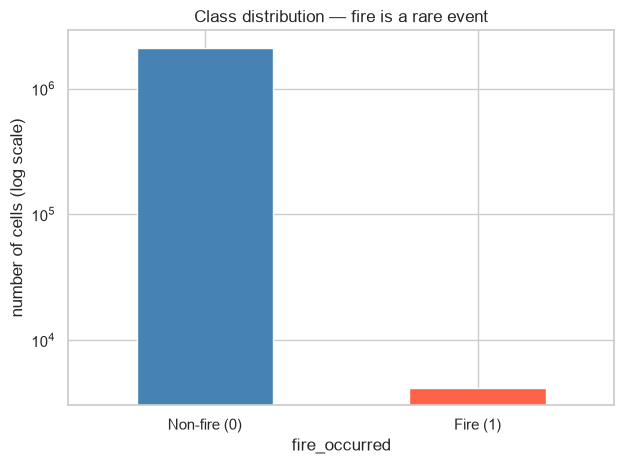

In [3]:
rate      = df["fire_occurred"].mean()
imbalance = (df["fire_occurred"] == 0).sum() / max(n_fire, 1)
print(f"Fire rate           : {rate:.3%}")
print(f"non-fire : fire     = {imbalance:,.0f} : 1")

ax = df["fire_occurred"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
ax.set_xticklabels(["Non-fire (0)", "Fire (1)"], rotation=0)
ax.set_ylabel("number of cells (log scale)")
ax.set_yscale("log")
ax.set_title("Class distribution — fire is a rare event")
plt.tight_layout(); plt.show()

## Define the feature set $X$ and the target $y$

In [4]:
TOPO    = ["elevation_m", "slope_deg", "aspect_sin", "aspect_cos",
           "tri", "twi", "solar_radiation"]
CLIMATE = ["temp_max_mean_c", "wind_max_mean_kmh", "precip_fire_season_mm",
           "drought_factor", "fwi_proxy", "consec_dry_days_max"]
VEG     = ["ndvi_fire_season", "ndvi_premonsoon", "ndvi_anomaly",
           "evi", "nbr", "ndwi", "lst_fire_season_mean_c"]
HUMAN   = ["log_dist_to_road", "log_dist_to_settlement", "log_dist_to_forest_edge",
           "log_dist_to_cropland", "log_population_density"]
LAND    = ["lulc_code"]

FEATURES = TOPO + CLIMATE + VEG + HUMAN + LAND
TARGET   = "fire_occurred"

print(f"{len(FEATURES)} features across 5 themes")
for name, grp in [("topography", TOPO), ("climate", CLIMATE),
                  ("vegetation", VEG), ("human/distance", HUMAN), ("land cover", LAND)]:
    print(f"  {name:16s}: {grp}")

26 features across 5 themes
  topography      : ['elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos', 'tri', 'twi', 'solar_radiation']
  climate         : ['temp_max_mean_c', 'wind_max_mean_kmh', 'precip_fire_season_mm', 'drought_factor', 'fwi_proxy', 'consec_dry_days_max']
  vegetation      : ['ndvi_fire_season', 'ndvi_premonsoon', 'ndvi_anomaly', 'evi', 'nbr', 'ndwi', 'lst_fire_season_mean_c']
  human/distance  : ['log_dist_to_road', 'log_dist_to_settlement', 'log_dist_to_forest_edge', 'log_dist_to_cropland', 'log_population_density']
  land cover      : ['lulc_code']


## Train/test split — why **random** splitting fails for maps

In [5]:
BLOCK_DEG = 0.1                              # ~11 km tiles at this latitude
df["block_id"] = (np.floor(df["lat"] / BLOCK_DEG).astype(int).astype(str) + "_" +
                  np.floor(df["lon"] / BLOCK_DEG).astype(int).astype(str))

blocks = df["block_id"].unique()
rng = np.random.RandomState(RANDOM_STATE)
shuffled = rng.permutation(blocks)
n_test_blocks = int(0.20 * len(shuffled))
test_blocks   = set(shuffled[:n_test_blocks])

test_mask  = df["block_id"].isin(test_blocks).values
train_mask = ~test_mask

X = df[FEATURES]
y = df[TARGET].astype(int)
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"spatial blocks    : {len(blocks):,}  (holding out {len(test_blocks):,})")
print(f"train rows / fires: {len(X_train):,} / {int(y_train.sum()):,}")
print(f"test  rows / fires: {len(X_test):,} / {int(y_test.sum()):,}")

spatial blocks    : 230  (holding out 46)
train rows / fires: 1,680,339 / 3,404
test  rows / fires: 443,309 / 727


## 6 · Impute missing values and scale
* **Imputation** — a few features have occasional `NaN`s. We fill them with the
  **median** (robust to outliers). Tree models could handle `NaN` natively, but
  imputing keeps all seven models on an identical footing.
* **Scaling** — Logistic Regression and the MLP need features on a common scale
  (`StandardScaler` → mean 0, std 1). Tree models are scale-invariant and use the
  *un*scaled, imputed data.

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median").fit(X_train)
X_train_imp = imputer.transform(X_train)          # for tree models
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler().fit(X_train_imp)
X_train_sc = scaler.transform(X_train_imp)         # for LR + MLP
X_test_sc  = scaler.transform(X_test_imp)

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (neg/pos) = {neg_pos_ratio:,.1f}")
print("imputed + scaled matrices ready:", X_train_imp.shape)

scale_pos_weight (neg/pos) = 492.6
imputed + scaled matrices ready: (1680339, 26)


## 7 · Metrics — measuring a rare-event model honestly

| Metric | What it answers | Good for imbalance? |
|---|---|---|
| Accuracy | fraction of cells classified correctly | ❌ trivially fooled |
| **AUC-ROC** | can the model *rank* fire above non-fire? | ⚠️ optimistic (counts the huge non-fire class) |
| **AUC-PR** | of the cells it flags, how many truly burn, vs how many fires it catches | ✅ **our primary metric** |
| **F1** | balance of precision & recall at a chosen threshold | ✅ with a tuned threshold |

**AUC-PR** (area under the Precision–Recall curve) focuses on the rare positive
class, so it is the right headline number for fire.

The default decision threshold of `0.5` is almost never right for imbalanced
data — we instead pick the threshold that **maximises F1** on the holdout. The
helper below computes all of this and records it so we can rank models later.

In [7]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, classification_report)

results     = {}     # model name -> {metrics}
proba_store = {}      # model name -> predicted probabilities on the holdout

def evaluate(name, y_true, y_prob, show_report=False):
    """Score a model on the spatial holdout and remember the result."""
    ap  = average_precision_score(y_true, y_prob)      # AUC-PR  (primary)
    roc = roc_auc_score(y_true, y_prob)
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_i   = int(np.nanargmax(f1s))
    best_thr = float(thr[min(best_i, len(thr) - 1)])
    best_f1  = float(f1s[best_i])

    results[name]     = {"AUC_PR": ap, "AUC_ROC": roc, "best_F1": best_f1, "thr": best_thr}
    proba_store[name] = y_prob
    print(f"{name:16s}  AUC-PR={ap:.3f}   AUC-ROC={roc:.3f}   best-F1={best_f1:.3f} @thr={best_thr:.3f}")
    if show_report:
        print(classification_report(y_true, (y_prob >= best_thr).astype(int),
                                    target_names=["Non-fire", "Fire"], digits=3))
    return results[name]

## Model 1 — Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", n_jobs=-1)
lr.fit(X_train_sc, y_train)
evaluate("LogisticReg", y_test, lr.predict_proba(X_test_sc)[:, 1], show_report=True)

LogisticReg       AUC-PR=0.005   AUC-ROC=0.729   best-F1=0.021 @thr=0.798
              precision    recall  f1-score   support

    Non-fire      0.999     0.981     0.990    442582
        Fire      0.011     0.128     0.021       727

    accuracy                          0.980    443309
   macro avg      0.505     0.555     0.505    443309
weighted avg      0.997     0.980     0.988    443309



{'AUC_PR': 0.005165360927961283,
 'AUC_ROC': 0.729169636945463,
 'best_F1': 0.02052300547971251,
 'thr': 0.7976027131080627}

## 9 · Model 2 — Random Forest

**How it works.** Build hundreds of decision trees, each on a random bootstrap
sample of rows and a random subset of features, then **average** their votes.
The randomness de-correlates the trees so their errors cancel out.

**Strengths** — captures non-linearities and interactions for free, robust to
outliers and redundant features, gives feature importances.
**Weakness** — cannot extrapolate beyond the training range; large in memory.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_leaf=10,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
rf.fit(X_train_imp, y_train)
evaluate("RandomForest", y_test, rf.predict_proba(X_test_imp)[:, 1])

RandomForest      AUC-PR=0.007   AUC-ROC=0.737   best-F1=0.036 @thr=0.753


{'AUC_PR': 0.007316453047813816,
 'AUC_ROC': 0.7367394229549187,
 'best_F1': 0.03649265032020364,
 'thr': 0.7530184380907156}

## XGBoost and LightGBM (gradient boosting)

**How it works.** Where a forest builds trees *independently and averages*,
boosting builds them **sequentially**: each new tree is trained to fix the
**residual errors** of the trees so far. This usually squeezes out a bit more
accuracy on tabular data.

* **XGBoost** grows trees *level-wise* and handles `NaN` natively.
* **LightGBM** grows *leaf-wise* (deepens the most useful branch first) → often
  ~10× faster on large data.

In [10]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio, eval_metric="aucpr",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_clf.fit(X_train_imp, y_train)
evaluate("XGBoost", y_test, xgb_clf.predict_proba(X_test_imp)[:, 1])

XGBoost           AUC-PR=0.008   AUC-ROC=0.736   best-F1=0.035 @thr=0.852


{'AUC_PR': 0.008208878843826236,
 'AUC_ROC': 0.7355464749724229,
 'best_F1': 0.034572169072469,
 'thr': 0.8522943258285522}

In [11]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63, max_depth=-1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=-1,
)
lgb_clf.fit(X_train_imp, y_train)
evaluate("LightGBM", y_test, lgb_clf.predict_proba(X_test_imp)[:, 1])

LightGBM          AUC-PR=0.003   AUC-ROC=0.600   best-F1=0.013 @thr=1.000


{'AUC_PR': 0.003481632250559038,
 'AUC_ROC': 0.600126372031047,
 'best_F1': 0.013394962673137275,
 'thr': 1.0}

## Multi-Layer Perceptron

**How it works.** A feed-forward network stacks layers of weighted sums +
non-linear activations, learning its own feature combinations. For one feature
vector per cell, a 2-layer MLP is plenty.

**Strengths** — flexible non-linear learner. **Weaknesses** — data-hungry, needs
**scaled** inputs, and is not interpretable without SHAP.


In [12]:
from sklearn.neural_network import MLPClassifier

pres_idx = np.where(y_train.values == 1)[0]
neg_idx  = np.where(y_train.values == 0)[0]
bg_idx   = rng.choice(neg_idx, size=min(50_000, len(neg_idx)), replace=False)

neg_keep = rng.choice(neg_idx, size=len(pres_idx) * 10, replace=False)
bal_idx  = np.concatenate([pres_idx, neg_keep])
rng.shuffle(bal_idx)
print(f"MLP balanced training set: {len(bal_idx):,} rows "
      f"({len(pres_idx):,} fire / {len(neg_keep):,} non-fire)")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation="relu", alpha=1e-3,
    batch_size=256, learning_rate_init=1e-3, max_iter=60,
    early_stopping=True, random_state=RANDOM_STATE,
)
mlp.fit(X_train_sc[bal_idx], y_train.values[bal_idx])
evaluate("MLP", y_test, mlp.predict_proba(X_test_sc)[:, 1])

MLP balanced training set: 37,444 rows (3,404 fire / 34,040 non-fire)
MLP               AUC-PR=0.009   AUC-ROC=0.729   best-F1=0.034 @thr=0.459


{'AUC_PR': 0.00852353000604701,
 'AUC_ROC': 0.728939573656171,
 'best_F1': 0.03417721483560507,
 'thr': 0.4587513506412506}

## 14 · Compare all seven models

Now we line them up on the **same spatial holdout**, ranked by **AUC-PR**. Expect
the **boosted trees (XGBoost / LightGBM) and Random Forest** to lead, Logistic
Regression as a respectable baseline, and MaxEnt to sit a little apart (different
paradigm). The ROC and Precision–Recall curves show the same story visually.

Ranked by AUC-PR (higher = better):


,AUC_PR,AUC_ROC,best_F1,thr
MLP,0.0085,0.7289,0.0342,0.4588
XGBoost,0.0082,0.7355,0.0346,0.8523
RandomForest,0.0073,0.7367,0.0365,0.7530
LogisticReg,0.0052,0.7292,0.0205,0.7976
LightGBM,0.0035,0.6001,0.0134,1.0000


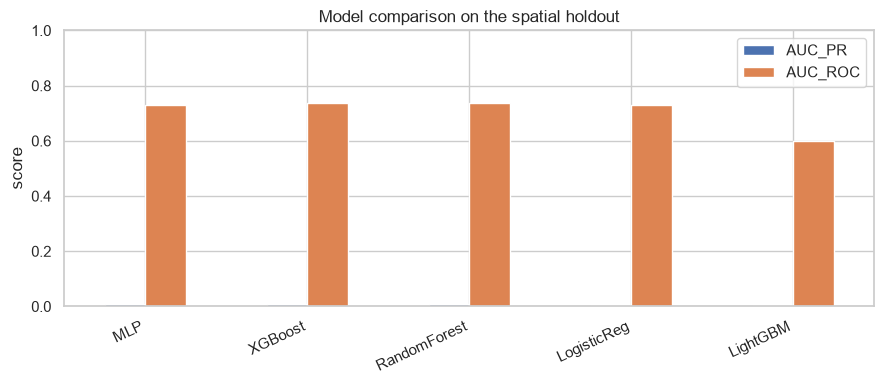

In [13]:
res_df = pd.DataFrame(results).T.sort_values("AUC_PR", ascending=False)
print("Ranked by AUC-PR (higher = better):")
display(res_df[["AUC_PR", "AUC_ROC", "best_F1", "thr"]].round(4))

ax = res_df[["AUC_PR", "AUC_ROC"]].plot(kind="bar", figsize=(9, 4))
ax.set_ylim(0, 1); ax.set_ylabel("score")
ax.set_title("Model comparison on the spatial holdout")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

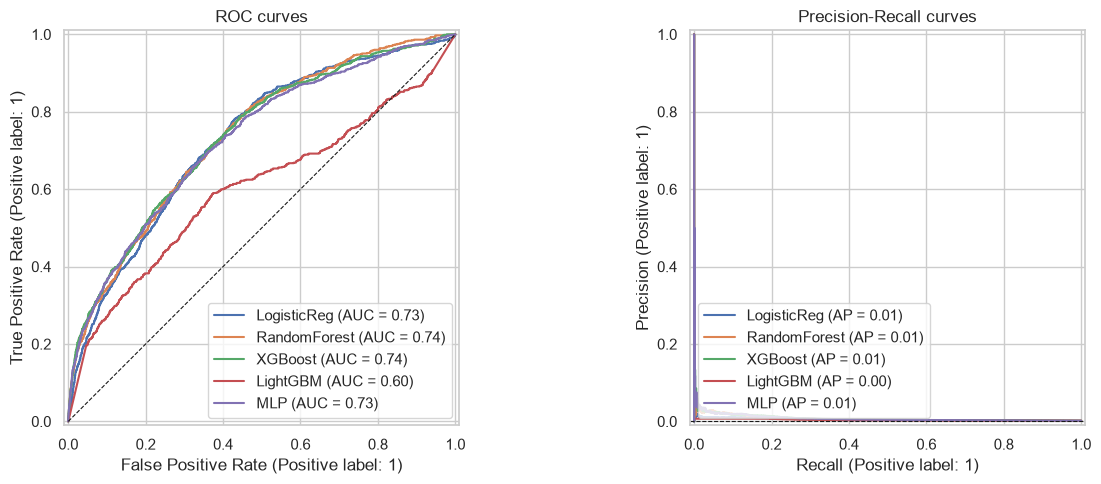

In [14]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, prob in proba_store.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=axes[1])
axes[0].set_title("ROC curves");          axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("Precision-Recall curves")
axes[1].axhline(rate, color="k", ls="--", lw=0.8, label="random")
plt.tight_layout(); plt.show()

## 15 · Robustness check — full 5-fold **spatial block** cross-validation

A single holdout could be lucky or unlucky. The gold standard is to rotate the
held-out blocks through **all** the data using `GroupKFold` with `block_id` as the
group — every block takes a turn as the test fold, and train/test never share a
block. We report the **mean ± std** of AUC-PR/ROC across folds, so a wide spread
warns us the model is unstable across regions.

We run this on the two strongest models (RF and XGBoost), per the guide's
recommendation. Pre-processing is rebuilt **inside each fold** to avoid leakage.

> ⏱️ **This is the slowest cell in the notebook** — it fits each model 5× on the
> full data (~10–20 min total). That patience is the price of an *honest* spatial
> score.

In [15]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone

groups_all = df["block_id"].values

def spatial_block_cv(estimator, n_splits=5, scale=False):
    gkf = GroupKFold(n_splits=n_splits)
    aps, rocs = [], []
    for k, (tr, te) in enumerate(gkf.split(X, y, groups_all), 1):
        steps = [("imp", SimpleImputer(strategy="median"))]
        if scale:
            steps.append(("sc", StandardScaler()))
        steps.append(("clf", clone(estimator)))
        pipe = Pipeline(steps).fit(X.iloc[tr], y.iloc[tr])
        p = pipe.predict_proba(X.iloc[te])[:, 1]
        aps.append(average_precision_score(y.iloc[te], p))
        rocs.append(roc_auc_score(y.iloc[te], p))
        print(f"  fold {k}:  AUC-PR={aps[-1]:.3f}   AUC-ROC={rocs[-1]:.3f}")
    print(f"  -> mean AUC-PR = {np.mean(aps):.3f} +/- {np.std(aps):.3f}   "
          f"AUC-ROC = {np.mean(rocs):.3f} +/- {np.std(rocs):.3f}\n")
    return aps, rocs

print("Random Forest - 5-fold spatial block CV")
spatial_block_cv(RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=10,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))

print("XGBoost - 5-fold spatial block CV")
spatial_block_cv(xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=neg_pos_ratio,
    tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE))

Random Forest - 5-fold spatial block CV
  fold 1:  AUC-PR=0.006   AUC-ROC=0.739
  fold 2:  AUC-PR=0.004   AUC-ROC=0.707
  fold 3:  AUC-PR=0.010   AUC-ROC=0.776
  fold 4:  AUC-PR=0.003   AUC-ROC=0.679
  fold 5:  AUC-PR=0.011   AUC-ROC=0.770
  -> mean AUC-PR = 0.007 +/- 0.003   AUC-ROC = 0.734 +/- 0.037

XGBoost - 5-fold spatial block CV
  fold 1:  AUC-PR=0.009   AUC-ROC=0.771
  fold 2:  AUC-PR=0.005   AUC-ROC=0.697
  fold 3:  AUC-PR=0.012   AUC-ROC=0.788
  fold 4:  AUC-PR=0.003   AUC-ROC=0.677
  fold 5:  AUC-PR=0.007   AUC-ROC=0.746
  -> mean AUC-PR = 0.007 +/- 0.003   AUC-ROC = 0.736 +/- 0.042



([0.00943285940771719,
  0.004659127242807834,
  0.011842388258762462,
  0.002901273184291528,
  0.006980367388792465],
 [0.7706060415058418,
  0.6965907894440765,
  0.7875168741872467,
  0.6773354407584975,
  0.7455254657863806])

## 16 · Is the winner *significantly* better? — McNemar's test

A 0.01 gap in AUC-PR might be real or just noise. Following Bilucan et al. (2024),
**McNemar's test** asks whether two models disagree *systematically* on the same
test cells. It counts cells where exactly one model is right; a small **p-value
(< 0.05)** means the difference is statistically significant, not luck.

In [16]:
from statsmodels.stats.contingency_tables import mcnemar

m1, m2 = "RandomForest", "XGBoost"
pred1 = (proba_store[m1] >= results[m1]["thr"]).astype(int)
pred2 = (proba_store[m2] >= results[m2]["thr"]).astype(int)
yv = y_test.values

b = int(((pred1 == yv) & (pred2 != yv)).sum())   # only m1 correct
c = int(((pred1 != yv) & (pred2 == yv)).sum())   # only m2 correct
res = mcnemar([[0, b], [c, 0]], exact=False, correction=True)

print(f"{m1}-only correct : {b:,}")
print(f"{m2}-only correct : {c:,}")
print(f"McNemar p-value   : {res.pvalue:.4g}  "
      f"-> {'significant' if res.pvalue < 0.05 else 'NOT significant'} difference")

RandomForest-only correct : 1,669
XGBoost-only correct : 219
McNemar p-value   : 7.836e-244  -> significant difference


## 17 · Interpretability — *why* does the model flag a cell?

A risk map nobody understands is hard to act on. **SHAP** (Lundberg & Lee 2017)
splits every prediction into additive per-feature contributions grounded in game
theory: a **positive** SHAP value pushes a cell *towards* fire, negative *away*.

The **beeswarm** plot below ranks features by overall impact. Each dot is a test
cell; colour is the feature value (red = high, blue = low). Reading it tells you,
e.g., whether *low pre-monsoon NDVI* (dry vegetation) or *short distance to
settlement* (human ignition) drives risk in Bagmati — and lets you sanity-check
the model against ecological knowledge.

We explain the **best tree model** with the fast `TreeExplainer`, on a 3 000-cell
sample of the holdout (SHAP on 400 k cells would be needlessly slow).

Explaining best tree model: XGBoost


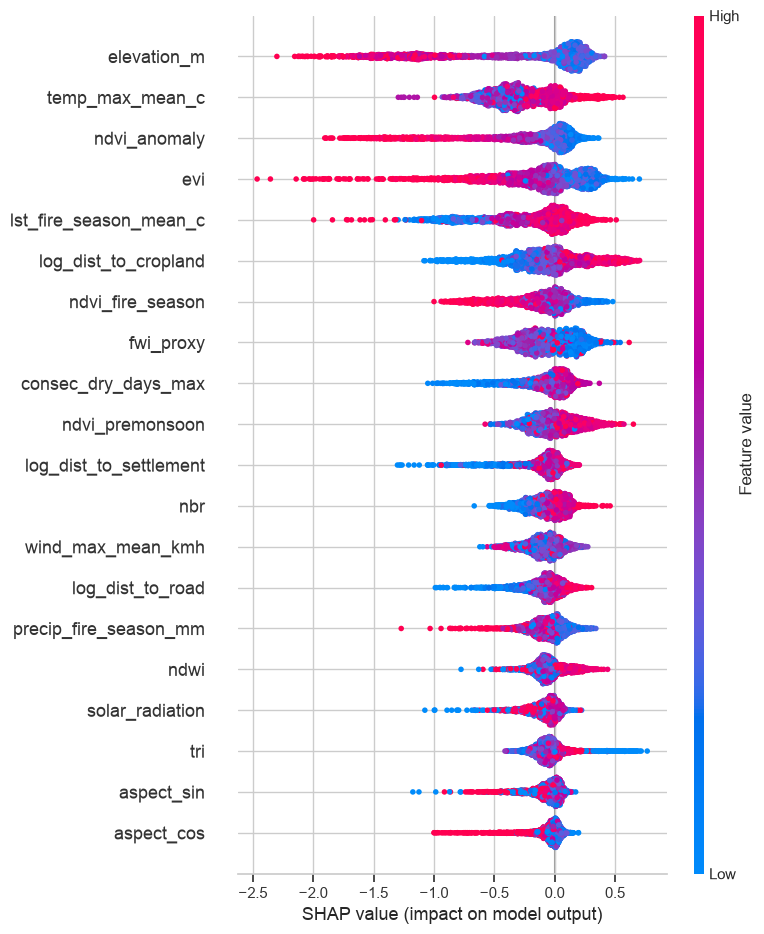

In [17]:
import shap

tree_models = {"RandomForest": rf, "XGBoost": xgb_clf, "LightGBM": lgb_clf}
best_tree_name = max(tree_models, key=lambda n: results[n]["AUC_PR"])
best_tree = tree_models[best_tree_name]
print(f"Explaining best tree model: {best_tree_name}")

sample_i = rng.choice(len(X_test_imp), size=min(3000, len(X_test_imp)), replace=False)
X_shap = X_test_imp[sample_i]

explainer   = shap.TreeExplainer(best_tree)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):            # some versions return [class0, class1]
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, show=True)

## 18 · The payoff — a province-wide susceptibility map

Finally we turn the best model into the deliverable: a probability for **every
flammable cell**, written back onto the canonical 100 m grid as a **GeoTIFF**,
and a 4-class **risk map** (Low / Moderate / High / Very High).

In [18]:
# 1) predict on ALL flammable cells with the overall best model
best_name = res_df.index[0]
model_registry = {
    "LogisticReg": (lr, "sc"), "RandomForest": (rf, "imp"),
    "XGBoost": (xgb_clf, "imp"), "LightGBM": (lgb_clf, "imp"),
    "MLP": (mlp, "sc"),
}
model, kind = model_registry[best_name]
print(f"Best overall model -> {best_name}  (used for the map)")

X_all_imp = imputer.transform(X)
if kind == "sc":
    prob_full = model.predict_proba(scaler.transform(X_all_imp))[:, 1]
elif kind == "maxent":
    prob_full = np.asarray(model.predict(pd.DataFrame(X_all_imp, columns=FEATURES))).ravel()
else:
    prob_full = model.predict_proba(X_all_imp)[:, 1]
df["fire_prob"] = prob_full
print(f"predicted {len(prob_full):,} probabilities  (mean {prob_full.mean():.3f})")

Best overall model -> MLP  (used for the map)
predicted 2,123,648 probabilities  (mean 0.081)


wrote fire_susceptibility_prob.tif


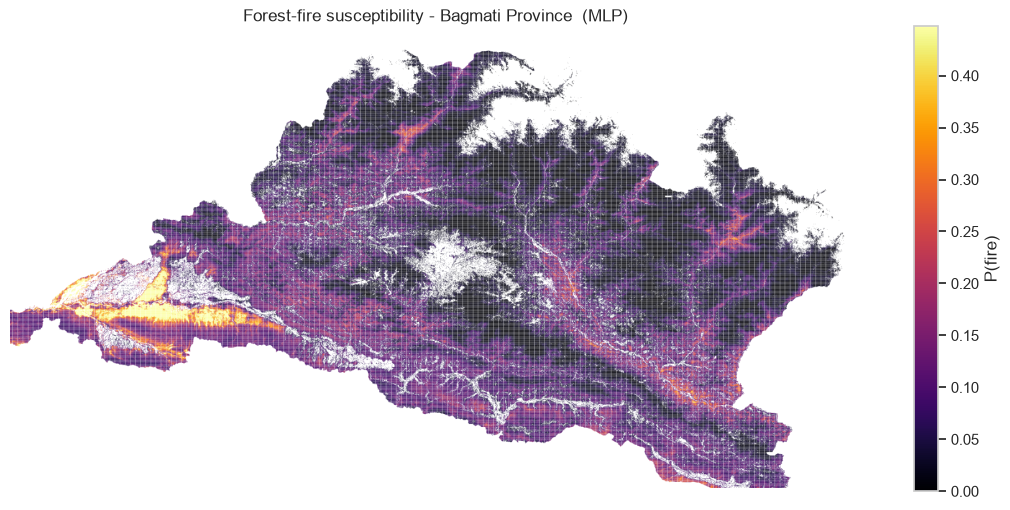

In [19]:
import rasterio

# 2) map each (lat, lon) back to a grid pixel using config's canonical grid
transform, W, H, crs = canonical_grid()
RES = GRID_RES_DEG
col = np.clip(np.round((df["lon"].values - STUDY_AREA["lon_min"]) / RES).astype(int), 0, W - 1)
row = np.clip(np.round((STUDY_AREA["lat_max"] - df["lat"].values) / RES).astype(int), 0, H - 1)

prob_raster = np.full((H, W), np.nan, dtype="float32")
prob_raster[row, col] = df["fire_prob"].values

# 3) save GeoTIFF
out_tif ="fire_susceptibility_prob.tif"
with rasterio.open(out_tif, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="float32", crs=crs, transform=transform,
                   compress="lzw", nodata=np.nan) as dst:
    dst.write(prob_raster, 1)
print("wrote", out_tif)

# 4) show it
plt.figure(figsize=(11, 7))
im = plt.imshow(prob_raster, cmap="inferno", vmin=0,
                vmax=np.nanpercentile(prob_raster, 99))
plt.colorbar(im, label="P(fire)", shrink=0.7)
plt.title(f"Forest-fire susceptibility - Bagmati Province  ({best_name})")
plt.axis("off"); plt.tight_layout(); plt.show()

### Risk classes via Jenks natural breaks

A continuous probability is hard for a planner to act on, so we bin it into four
**risk classes**. **Jenks natural breaks** chooses cut-points that minimise
within-class variance (it finds the "natural" gaps in the distribution). We fit
the breaks on a 50 k sample for speed, then apply them to every cell and save a
second GeoTIFF.

Jenks break points: [np.float32(0.001), np.float32(0.066), np.float32(0.149), np.float32(0.345), np.float32(0.816)]
  Low       :  52.2% of flammable area
  Moderate  :  35.8% of flammable area
  High      :  10.3% of flammable area
  Very High :   1.7% of flammable area
wrote fire_susceptibility_risk_class.tif


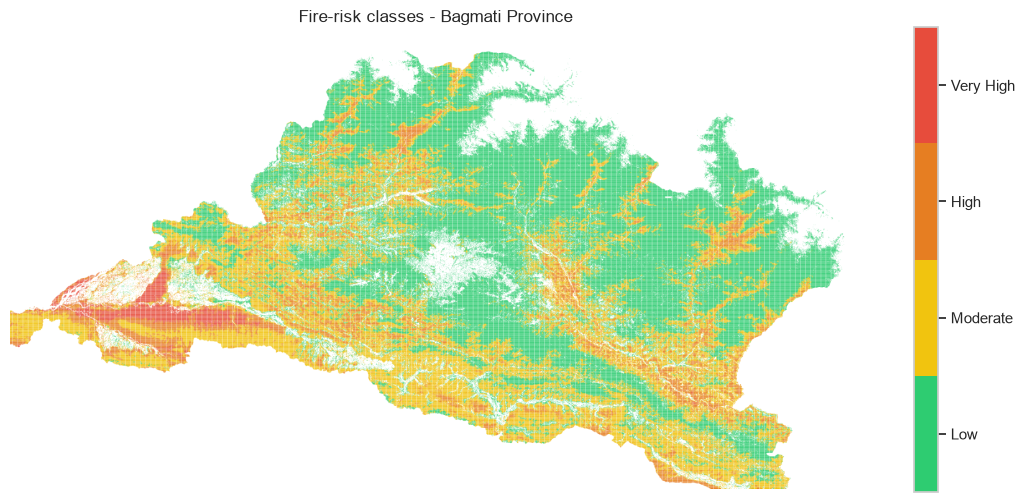

In [20]:
import jenkspy
import matplotlib.colors as mcolors

valid   = df["fire_prob"].values
sample  = rng.choice(valid, size=min(50_000, len(valid)), replace=False)
breaks  = jenkspy.jenks_breaks(sample, n_classes=4)
risk    = np.digitize(df["fire_prob"].values, bins=breaks[1:-1])  # 0..3

labels = ["Low", "Moderate", "High", "Very High"]
print("Jenks break points:", [round(b, 3) for b in breaks])
for c, lab in enumerate(labels):
    print(f"  {lab:10s}: {(risk == c).mean():6.1%} of flammable area")

risk_raster = np.full((H, W), np.nan, dtype="float32")
risk_raster[row, col] = risk.astype("float32")

out_risk = "fire_susceptibility_risk_class.tif"
with rasterio.open(out_risk, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="float32", crs=crs, transform=transform,
                   compress="lzw", nodata=np.nan) as dst:
    dst.write(risk_raster, 1)
print("wrote", out_risk)

cmap = mcolors.ListedColormap(["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"])
plt.figure(figsize=(11, 7))
im = plt.imshow(risk_raster, cmap=cmap, vmin=-0.5, vmax=3.5)
cbar = plt.colorbar(im, ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(labels)
plt.title("Fire-risk classes - Bagmati Province")
plt.axis("off"); plt.tight_layout(); plt.show()

## 19 · Persist the trained models for validation

So that a separate notebook can re-load these exact models and test them against
the **2026** fire hotspots (data never seen during training), we serialise every
fitted model together with the `imputer`, `scaler`, the feature order, the
per-model best-F1 thresholds, the AUC-PR ranking, and the Jenks risk breaks into
a single `joblib` bundle under `outputs/models/`.

In [ ]:
import joblib

MODELS_DIR = ROOT / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sklearn_bundle = {
    "models": {                                  # all five fitted estimators
        "LogisticReg":  lr,
        "RandomForest": rf,
        "XGBoost":      xgb_clf,
        "LightGBM":     lgb_clf,
        "MLP":          mlp,
    },
    "model_kind": {                              # which matrix each one expects
        "LogisticReg": "sc", "RandomForest": "imp", "XGBoost": "imp",
        "LightGBM": "imp", "MLP": "sc",
    },
    "imputer":      imputer,                     # SimpleImputer(median)
    "scaler":       scaler,                      # StandardScaler (for sc models)
    "features":     FEATURES,                    # exact 26-column order
    "thresholds":   {k: results[k]["thr"] for k in results},
    "res_df":       res_df,                      # AUC-PR ranking; best = index[0]
    "jenks_breaks": [float(b) for b in breaks],  # 4-class risk cut-points
    "risk_labels":  ["Low", "Moderate", "High", "Very High"],
    "random_state": RANDOM_STATE,
    "block_deg":    BLOCK_DEG,
}

out_path = MODELS_DIR / "sklearn_models.joblib"
joblib.dump(sklearn_bundle, out_path)

print("saved bundle ->", out_path)
print("  models       :", list(sklearn_bundle["models"]))
print("  best (AUC-PR):", res_df.index[0])
print("  jenks breaks :", [round(b, 3) for b in sklearn_bundle["jenks_breaks"]])

saved bundle -> /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/models/sklearn_models.joblib
  models       : ['LogisticReg', 'RandomForest', 'XGBoost', 'LightGBM', 'MLP']
  best (AUC-PR): MLP
  jenks breaks : [0.001, 0.066, 0.149, 0.345, 0.816]


: 